In [1]:
# Make a directory named '.kaggle'
!mkdir -p ~/.kaggle

# Move the kaggle.json file to the '.kaggle' folder
!mv kaggle.json ~/.kaggle/
!kaggle datasets download -d arkhoshghalb/twitter-sentiment-analysis-hatred-speech

mv: cannot stat 'kaggle.json': No such file or directory
Dataset URL: https://www.kaggle.com/datasets/arkhoshghalb/twitter-sentiment-analysis-hatred-speech
License(s): unknown
  0% 0.00/1.89M [00:00<?, ?B/s]
100% 1.89M/1.89M [00:00<00:00, 54.4MB/s]


In [2]:
## Extract the zip file
import zipfile
zip_ref = zipfile.ZipFile('/content/twitter-sentiment-analysis-hatred-speech.zip')
zip_ref.extractall('/content')
zip_ref.close()

In [3]:
import pandas as pd
import numpy as np

In [4]:
train_df = pd.read_csv('/content/train.csv')
train_df.head()

,id,label,tweet
0,1,0,@user when a father is dysfunctional and is s...
1,2,0,@user @user thanks for #lyft credit i can't us...
2,3,0,bihday your majesty
3,4,0,#model i love u take with u all the time in ...
4,5,0,factsguide: society now #motivation


In [5]:
train_df.label.value_counts()

,count
label,
0,29720
1,2242


As clear from above data that our dataframe is imbalanced

In [6]:
## Import Global vectors GloVe
!wget http://downloads.cs.stanford.edu/nlp/data/glove.6B.zip

--2024-08-25 10:43:13--  http://downloads.cs.stanford.edu/nlp/data/glove.6B.zip
Resolving downloads.cs.stanford.edu (downloads.cs.stanford.edu)... 171.64.64.22
Connecting to downloads.cs.stanford.edu (downloads.cs.stanford.edu)|171.64.64.22|:80... connected.
HTTP request sent, awaiting response... 200 OK
Length: 862182613 (822M) [application/zip]
Saving to: ‘glove.6B.zip’

glove.6B.zip        100%[===================>] 822.24M  5.24MB/s    in 2m 39s  

2024-08-25 10:45:53 (5.16 MB/s) - ‘glove.6B.zip’ saved [862182613/862182613]



In [7]:
!unzip glove.6B.zip

Archive:  glove.6B.zip
  inflating: glove.6B.50d.txt        
  inflating: glove.6B.100d.txt       
  inflating: glove.6B.200d.txt       
  inflating: glove.6B.300d.txt       


In [8]:
with open('glove.6B.50d.txt','r') as f:
  lines = f.readlines()
  for line in range(1):
    print(lines[line])

the 0.418 0.24968 -0.41242 0.1217 0.34527 -0.044457 -0.49688 -0.17862 -0.00066023 -0.6566 0.27843 -0.14767 -0.55677 0.14658 -0.0095095 0.011658 0.10204 -0.12792 -0.8443 -0.12181 -0.016801 -0.33279 -0.1552 -0.23131 -0.19181 -1.8823 -0.76746 0.099051 -0.42125 -0.19526 4.0071 -0.18594 -0.52287 -0.31681 0.00059213 0.0074449 0.17778 -0.15897 0.012041 -0.054223 -0.29871 -0.15749 -0.34758 -0.045637 -0.44251 0.18785 0.0027849 -0.18411 -0.11514 -0.78581



In [9]:
## Add word vectors to a dict
word_vectors = dict()
def add_word_vectors(d, file):
  with open(file, 'r') as f:
    for line in f.readlines() :
      line = line.split(' ')
      ## Use Exception Handling to avoid errors
      try:
        d[line[0]] = np.array(line[1:], dtype = 'float32')
      except:
        continue

add_word_vectors(word_vectors, 'glove.6B.50d.txt')



In [10]:
len(word_vectors)

400000

In [11]:
import nltk
nltk.download('punkt')
nltk.download('wordnet')

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.
[nltk_data] Downloading package wordnet to /root/nltk_data...


True

In [12]:
from nltk.stem import WordNetLemmatizer
from nltk.tokenize import RegexpTokenizer

tokenizer = RegexpTokenizer(r"\w+")
lemmatizer = WordNetLemmatizer()

def message_to_token_list(s):
  tokens = tokenizer.tokenize(s)
  lowercased_tokens = [t.lower() for t in tokens]
  lemmatized_tokens = [lemmatizer.lemmatize(t) for t in lowercased_tokens]
  useful_tokens = [t for t in lemmatized_tokens if t in word_vectors]

  return useful_tokens

In [13]:
## Convert a whole tweet to it's word vect0r

def message_to_word_vectors(message, word_dict=word_vectors):
  processed_list_of_tokens = message_to_token_list(message)

  vectors = []

  for token in processed_list_of_tokens:
    if token not in word_dict:
      continue

    token_vector = word_dict[token]
    vectors.append(token_vector)

  return np.array(vectors, dtype=float)

In [14]:
message_to_word_vectors('@user when a father is dysfunctional and is atuuda ').shape

(8, 50)

## Split The Data into Train, Test and Validation Data

In [15]:
train_df = train_df.sample(frac=1, random_state=1)
train_df.reset_index(drop=True, inplace=True)

split_index_1 = int(len(train_df) * 0.7)
split_index_2 = int(len(train_df) * 0.85)

train_df, val_df, test_df = train_df[:split_index_1], train_df[split_index_1:split_index_2], train_df[split_index_2:]

len(train_df), len(val_df), len(test_df)

(22373, 4794, 4795)

In [16]:
val_df

,id,label,tweet
22373,3296,0,@user looking forward to the game tonight co...
22374,18917,0,shoes are stored. pillows and blankets out. ti...
22375,1498,0,going to a conce a guy checks in goes through ...
22376,10808,0,#petal polar bear climb racing: angry polar ...
22377,5293,0,read this and choose happiness now! #blogg...
...,...,...,...
27162,14753,0,"@user ""cheer me up!"" - @user #sexysunday #on..."
27163,29640,0,@user odd that you keep saying that you aren'...
27164,22301,0,truthâ¼ï¸ðâ¤ï¸ #truth #goodmorning #ige...
27165,19925,0,camiilabeckeer #divulgaÃ§Ã£oeparceria #inshot...


In [17]:
def df_to_X_y(df):
  y = df['label'].to_numpy().astype('int')
  X = []
  for message in df['tweet']:
    message_as_vector_seq = message_to_word_vectors(message)

    if message_as_vector_seq.shape[0] == 0:
      message_as_vector_seq = np.zeros(shape=(1, 50))

    X.append(message_as_vector_seq)

  return X, y

In [18]:
X_train, y_train = df_to_X_y(train_df)

print(len(X_train), len(X_train[0]))

22373 13


(array([3.493e+03, 7.017e+03, 6.723e+03, 3.786e+03, 1.182e+03, 1.610e+02,
        7.000e+00, 0.000e+00, 1.000e+00, 3.000e+00]),
 array([ 1. ,  6.4, 11.8, 17.2, 22.6, 28. , 33.4, 38.8, 44.2, 49.6, 55. ]),
 <BarContainer object of 10 artists>)

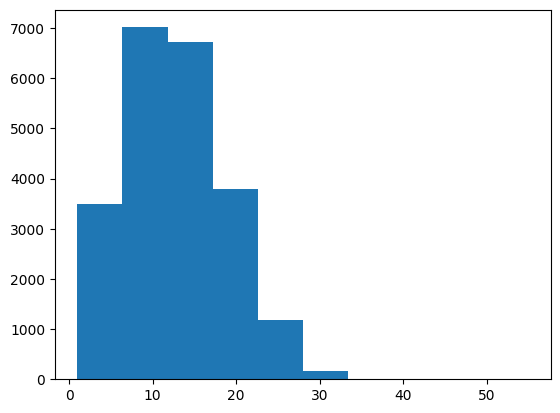

In [19]:
## Distribution of tweet lengths
import matplotlib.pyplot as plt
tweet_lengths = [len(x) for x in X_train]
plt.hist(tweet_lengths)

In [20]:
pd.Series(tweet_lengths).describe()

,0
count,22373.000000
mean,12.692308
std,5.929912
min,1.000000
25%,8.000000
50%,12.000000
75%,17.000000
max,55.000000


Minimum tweet length is 1 and max length is 55. We will have to add zero padding to make all tweet vectors of same dimension.

In [21]:
from copy import deepcopy

In [22]:
def add_padding(X, desired_len = 60):
  copy = deepcopy(X)

  for idx, x in enumerate(X) :
    x_len = x.shape[0]
    padding_len = desired_len - x_len
    pad = np.zeros(shape = (padding_len, 50))
    copy[idx] = np.concatenate([x,pad])
  return np.array(copy).astype('float')


In [23]:
X_test, y_test = df_to_X_y(test_df)
X_val, y_val = df_to_X_y(val_df)

In [24]:
X_train = add_padding(X_train)
X_test = add_padding(X_test)
X_val = add_padding(X_val)

X_train.shape, X_test.shape, X_val.shape

((22373, 60, 50), (4795, 60, 50), (4794, 60, 50))

# Let's Build Our Model

In [25]:
from tensorflow.keras import layers
from tensorflow.keras.models import Sequential
from tensorflow.keras.metrics import AUC
from tensorflow.keras.callbacks import ModelCheckpoint

In [26]:
model = Sequential()

model.add(layers.Input(shape=(60, 50)))

model.add(layers.LSTM(128, return_sequences=True))
model.add(layers.Dropout(0.2))

model.add(layers.LSTM(128, return_sequences=True))
model.add(layers.Dropout(0.2))

model.add(layers.LSTM(64, return_sequences=True))
model.add(layers.Dropout(0.2))

model.add(layers.LSTM(64, return_sequences=True))
model.add(layers.Dropout(0.2))

model.add(layers.Flatten())

model.add(layers.Dense(1, activation='sigmoid'))

model.compile(optimizer = 'adam',
              loss = 'binary_crossentropy',
              metrics=['accuracy', AUC(name='auc')])

cp = ModelCheckpoint('model.keras', save_best_only = True)
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                          │ (None, 60, 128)             │          91,648 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 60, 128)             │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ lstm_1 (LSTM)                        │ (None, 60, 128)             │         131,584 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_1 (Dropout)                  │ (None, 60, 128)             │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ lstm_2 (LSTM)                        │ (None, 60, 64)              │          49,408 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_2 (Dropout)                  │ (None, 60, 64)              │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ lstm_3 (LSTM)                        │ (None, 60, 64)              │          33,024 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_3 (Dropout)                  │ (None, 60, 64)              │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten (Flatten)                    │ (None, 3840)                │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 1)                   │           3,841 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 309,505 (1.18 MB)

 Trainable params: 309,505 (1.18 MB)

 Non-trainable params: 0 (0.00 B)

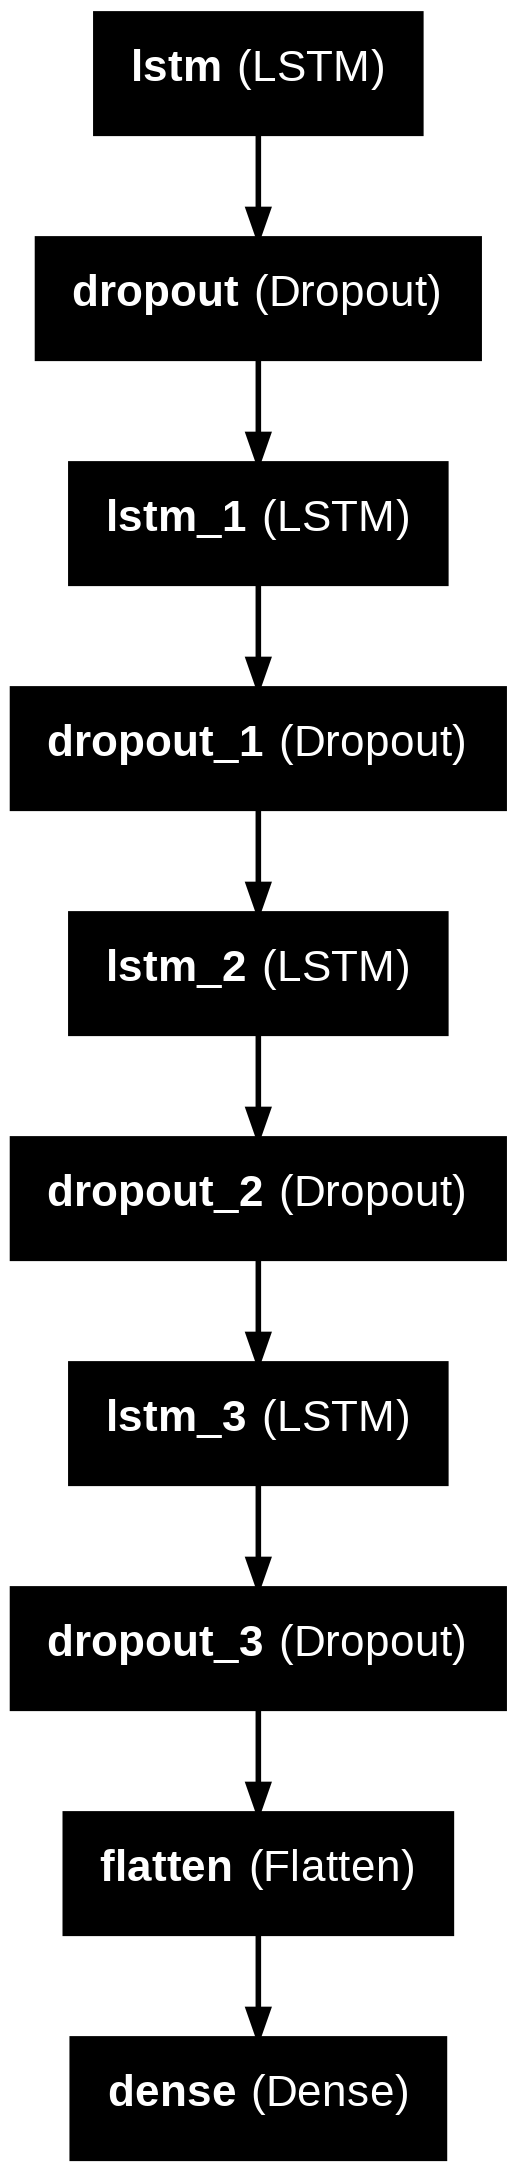

<Figure size 1000x1000 with 0 Axes>

In [32]:
plt.figure(figsize = (10,10))
from keras.utils import plot_model
plot_model(model, show_layer_names = True)

In [33]:
model.fit(X_train, y_train, validation_data=(X_val, y_val), epochs=20, callbacks=[cp])

Epoch 1/20
700/700 ━━━━━━━━━━━━━━━━━━━━ 13s 18ms/step - accuracy: 0.9979 - auc: 0.9998 - loss: 0.0062 - val_accuracy: 0.9535 - val_auc: 0.8013 - val_loss: 0.3706
Epoch 2/20
700/700 ━━━━━━━━━━━━━━━━━━━━ 19s 27ms/step - accuracy: 0.9979 - auc: 0.9996 - loss: 0.0069 - val_accuracy: 0.9556 - val_auc: 0.8416 - val_loss: 0.3383
Epoch 3/20
700/700 ━━━━━━━━━━━━━━━━━━━━ 16s 21ms/step - accuracy: 0.9991 - auc: 0.9986 - loss: 0.0023 - val_accuracy: 0.9539 - val_auc: 0.8373 - val_loss: 0.3920
Epoch 4/20
700/700 ━━━━━━━━━━━━━━━━━━━━ 18s 18ms/step - accuracy: 0.9993 - auc: 0.9989 - loss: 0.0033 - val_accuracy: 0.9470 - val_auc: 0.8449 - val_loss: 0.3810
Epoch 5/20
700/700 ━━━━━━━━━━━━━━━━━━━━ 22s 20ms/step - accuracy: 0.9989 - auc: 0.9995 - loss: 0.0046 - val_accuracy: 0.9552 - val_auc: 0.8354 - val_loss: 0.3233
Epoch 6/20
700/700 ━━━━━━━━━━━━━━━━━━━━ 21s 21ms/step - accuracy: 0.9989 - auc: 0.9996 - loss: 0.0033 - val_accuracy: 0.9539 - val_auc: 0.8233 - val_loss: 0.3550
Epoch 7/20
700/700 ━━━━━━━━━

In [35]:
from tensorflow.keras.models import load_model

best_model = load_model('model.keras')

Validating Model On Test Data

In [36]:
test_predictions = (best_model.predict(X_test) > 0.5).astype(int)

from sklearn.metrics import classification_report

print(classification_report(y_test, test_predictions))

150/150 ━━━━━━━━━━━━━━━━━━━━ 3s 12ms/step
              precision    recall  f1-score   support

           0       0.97      0.98      0.98      4454
           1       0.70      0.61      0.65       341

    accuracy                           0.95      4795
   macro avg       0.84      0.80      0.81      4795
weighted avg       0.95      0.95      0.95      4795

